In [1]:
import pandas as pd

In [11]:
df=pd.read_csv("customer_analytics.csv")
print(df.head())
print(df.info())
print(df.describe())

   CustomerID  Age  Gender    City  Education MaritalStatus  AnnualIncome  \
0        1001   49    Male    Pune    Masters        Single       82953.0   
1        1002   44    Male    Pune        PhD        Single       60610.0   
2        1003   42    Male  Mumbai  Bachelors        Single       35501.0   
3        1004   36  Female  Mumbai    Masters       Married       99312.0   
4        1005   23    Male    Pune    Masters       Married       46980.0   

   SpendingScore  YearsEmployed  PurchaseFrequency  OnlineVisitsPerMonth  \
0             66             23                 19                     9   
1             56             22                  1                    23   
2             44             18                 10                    29   
3             36             10                 12                    21   
4             56              1                 18                     9   

   ReturnedItems PreferredDevice  LastPurchaseAmount  
0              2         

The head() output displays the first few records, helping us understand the structure and sample values of the dataset.

The info() output shows data types and confirms the presence of missing values, while describe() provides summary statistics like mean, min, max, and standard deviation for numerical columns.

In [12]:
df.isnull().sum()

CustomerID               0
Age                      0
Gender                   0
City                     0
Education               12
MaritalStatus            0
AnnualIncome            12
SpendingScore            0
YearsEmployed            0
PurchaseFrequency        0
OnlineVisitsPerMonth     0
ReturnedItems            0
PreferredDevice          0
LastPurchaseAmount       0
dtype: int64

This output shows the total number of missing values in each column.
It helps identify which variables require data cleaning or imputation before further analysis.

In [13]:
df["Education"]=df["Education"].fillna(df["Education"].mode()[0])
df["AnnualIncome"] = df["AnnualIncome"].fillna(df["AnnualIncome"].mean())
df.isnull().sum()

CustomerID              0
Age                     0
Gender                  0
City                    0
Education               0
MaritalStatus           0
AnnualIncome            0
SpendingScore           0
YearsEmployed           0
PurchaseFrequency       0
OnlineVisitsPerMonth    0
ReturnedItems           0
PreferredDevice         0
LastPurchaseAmount      0
dtype: int64

Missing values in categorical and numerical columns were handled using mode and median respectively.
The output confirms that all missing values have been successfully treated.

In [14]:
df.duplicated().sum()

np.int64(5)

the output checks the number of duplicate rows on the dataset it ensures that repeted records do not basic the analysis

In [15]:
df = df.drop_duplicates()

the second duplicate check confirms whether duplicate entries exit after preprcessing.A value of zero indicates the dataset contains only unique records.

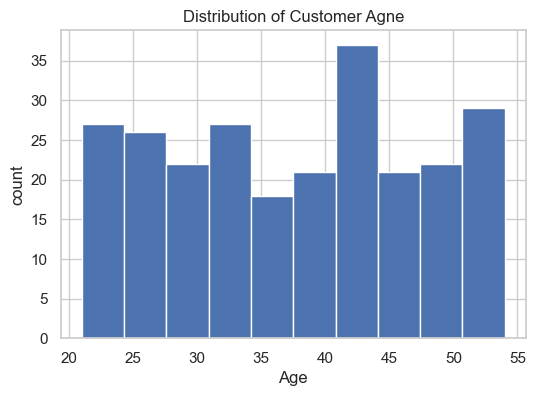

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=10)
plt.title("Distribution of Customer Agne")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

the histrogram shows how customers ages are distributed across differnt age groups. It helps idetifiy yhe most common age range and detect any skewness in age distribution.

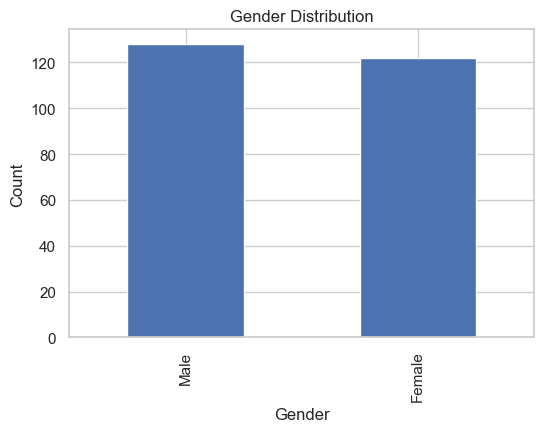

In [19]:
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

the bar represtation the count of customers by gender. It helps understand the gender composition of the customer base

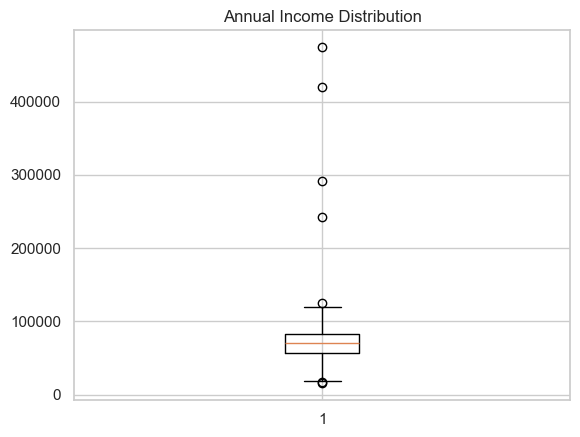

In [21]:
plt.figure()
plt.boxplot(df['AnnualIncome'].dropna())
plt.title("Annual Income Distribution")
plt.show()

the box plote compares spending across genders.It highlights differnces in median spending score and shows any outliers.

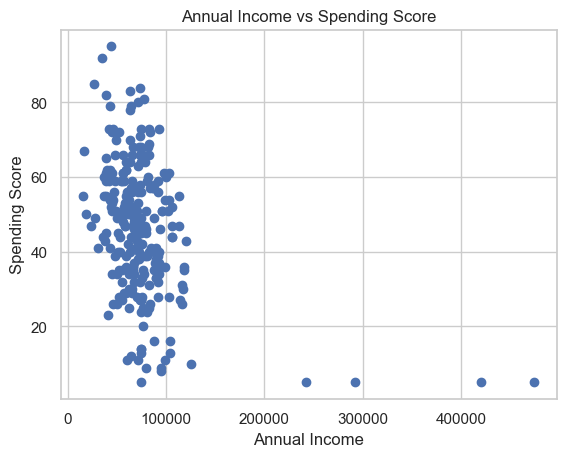

In [22]:
plt.figure()
plt.scatter(df['AnnualIncome'], df['SpendingScore'])
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

customers with higher do not always spend more.Spending behavior varies across income levels

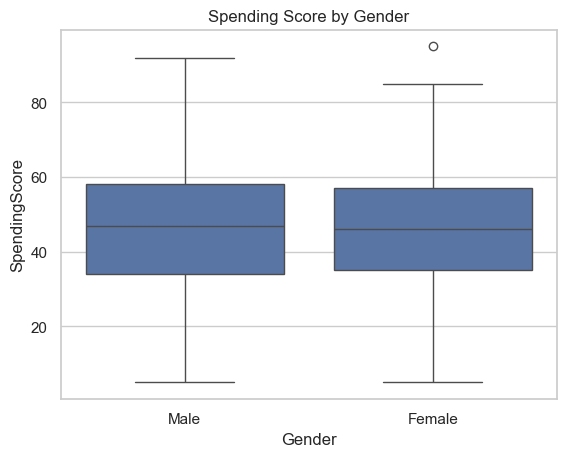

In [23]:
plt.figure()
sns.boxplot(x='Gender', y='SpendingScore', data=df)
plt.title("Spending Score by Gender")
plt.show()

the boxes plot summarizes income distributation and idetifies extreme vlues(outliers).It pravires a chear view of medaian  income and overall spread

In [24]:
corr = df.corr(numeric_only=True)
corr

,CustomerID,Age,AnnualIncome,SpendingScore,YearsEmployed,PurchaseFrequency,OnlineVisitsPerMonth,ReturnedItems,LastPurchaseAmount
CustomerID,1.000000,-0.038170,-0.039649,0.070869,-0.018877,-0.077040,-0.029642,0.023180,-0.034412
Age,-0.038170,1.000000,-0.051910,-0.006943,0.975242,0.103053,-0.033532,-0.051190,0.092891
AnnualIncome,-0.039649,-0.051910,1.000000,-0.386146,-0.054428,-0.037018,0.092756,-0.113211,-0.015953
SpendingScore,0.070869,-0.006943,-0.386146,1.000000,-0.017487,0.009792,-0.072441,0.057686,0.032737
YearsEmployed,-0.018877,0.975242,-0.054428,-0.017487,1.000000,0.073113,-0.052168,-0.050904,0.114464
PurchaseFrequency,-0.077040,0.103053,-0.037018,0.009792,0.073113,1.000000,-0.041362,0.084121,-0.068246
OnlineVisitsPerMonth,-0.029642,-0.033532,0.092756,-0.072441,-0.052168,-0.041362,1.000000,-0.071400,0.010528
ReturnedItems,0.023180,-0.051190,-0.113211,0.057686,-0.050904,0.084121,-0.071400,1.000000,0.016208
LastPurchaseAmount,-0.034412,0.092891,-0.015953,0.032737,0.114464,-0.068246,0.010528,0.016208,1.000000


The correlation matrix shows the strength and direction of relationships between numerical variables.
Values closer to +1 or -1 indicate strong relationships, while values near 0 indicate weak relationships.

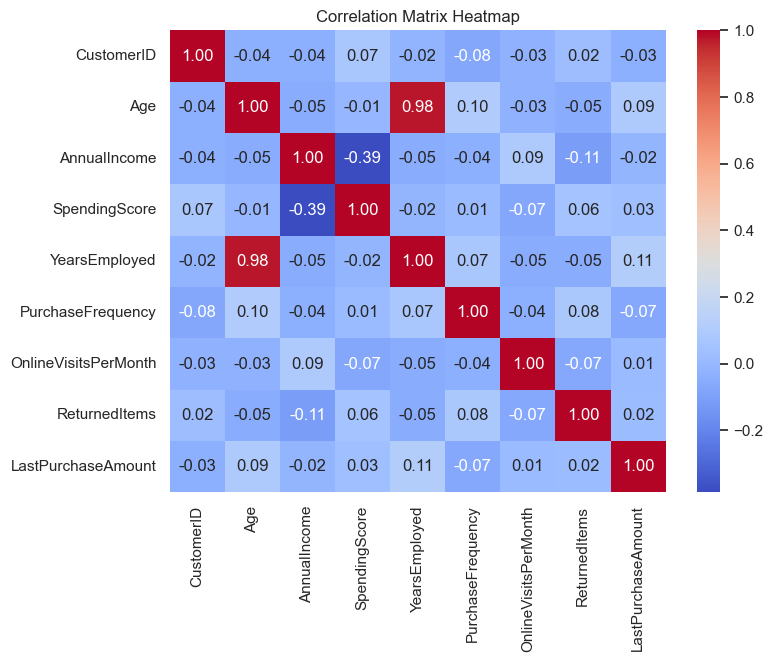

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
The heatmap visually represents correlations between multiple variables using color intensity.
It helps quickly identify strong positive or negative relationships in the dataset.